# ARMA & ARIMA Models

**Navigation**: [← Previous: Fourier Analysis](04_fourier.ipynb) | [Next: SARIMA →](06_sarima.ipynb)

ARIMA models capture autocorrelation structure via autoregressive and moving-average components, with differencing to achieve stationarity.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR = Path('data')
if not DATA_DIR.exists():
    DATA_DIR = Path('projects/time-series-analysis/data')

def load_series(name):
    """Load a bundled CSV as a DatetimeIndex Series."""
    df = pd.read_csv(DATA_DIR / name, parse_dates=['date'])
    return df.set_index('date')['value'].sort_index()

def load_air_passengers():
    path = DATA_DIR / 'air_passengers.csv'
    if path.exists():
        return load_series('air_passengers.csv')
    from statsmodels.datasets import get_rdataset
    air = get_rdataset('AirPassengers', 'datasets').data
    s = air['value']
    s.index = pd.date_range('1949-01', periods=len(s), freq='MS')
    return s

def load_milk():
    path = DATA_DIR / 'monthly_milk.csv'
    if path.exists():
        return load_series('monthly_milk.csv')
    url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-milk-production-pounds.csv'
    return pd.read_csv(url, index_col=0, parse_dates=True).squeeze()

def load_co2():
    from statsmodels.datasets import co2
    return co2.load().data.resample('MS').mean().ffill().squeeze()

def load_sunspots():
    from statsmodels.datasets import sunspots
    d = sunspots.load_pandas().data
    return d.set_index('YEAR')['SUNACTIVITY']

def load_retail():
    path = DATA_DIR / 'uk_retail_sales.csv'
    if path.exists():
        return load_series('uk_retail_sales.csv')
    raise FileNotFoundError('uk_retail_sales.csv not found in data/')
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## Unit Root Tests

ADF: $H_0$ = unit root. KPSS: $H_0$ = stationarity. Use both together.

In [2]:

air = load_air_passengers()
spots = load_sunspots().astype(float)

for name, s in [('Air Passengers', air), ('Sunspots', spots)]:
    adf = adfuller(s.dropna())
    kpss_stat, kpss_p, _, _ = kpss(s.dropna(), regression='c', nlags='auto')
    print(f'{name}: ADF p={adf[1]:.4f}  KPSS p={kpss_p:.4f}')


Air Passengers: ADF p=0.9919  KPSS p=0.0100
Sunspots: ADF p=0.0531  KPSS p=0.0163


/var/folders/6j/s6_5p4dj51nbsz36mmbs50680000gn/T/ipykernel_45560/236599001.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(s.dropna(), regression='c', nlags='auto')


## AR(2) on Sunspots

PACF cuts off at lag $p$ for AR($p$); sunspots are classically modelled as AR(2).

In [3]:

spots = load_sunspots().astype(float).loc[1900:2008]
model_ar2 = ARIMA(spots, order=(2, 0, 0)).fit()
print(model_ar2.summary().tables[1])
lb = acorr_ljungbox(model_ar2.resid, lags=[10, 20], return_df=True)
print('Ljung-Box on residuals:\n', lb)


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         60.2268      6.959      8.655      0.000      46.588      73.865
ar.L1          1.3967      0.074     18.753      0.000       1.251       1.543
ar.L2         -0.7145      0.065    -10.939      0.000      -0.843      -0.586
sigma2       364.8236     48.322      7.550      0.000     270.113     459.534
Ljung-Box on residuals:
       lb_stat  lb_pvalue
10  26.849990   0.002750
20  39.813484   0.005274


/Users/areeslindley/.pyenv/versions/3.13.0/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/areeslindley/.pyenv/versions/3.13.0/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/areeslindley/.pyenv/versions/3.13.0/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


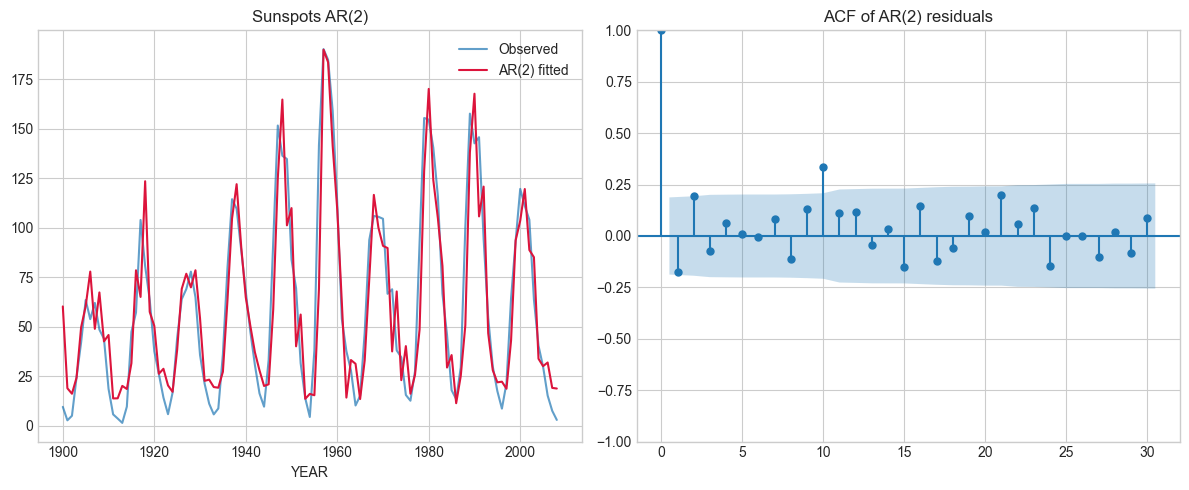

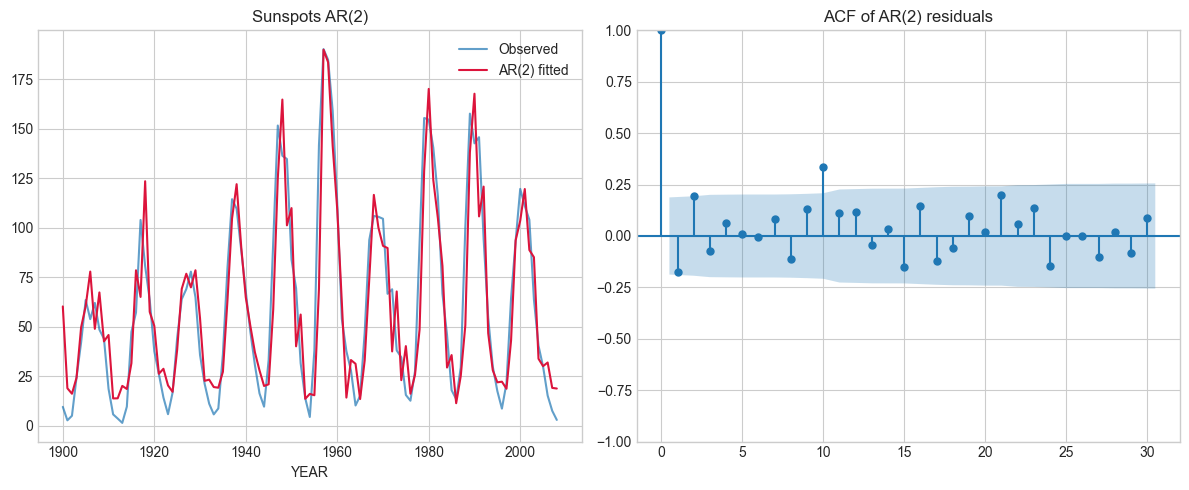

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
spots.plot(ax=axes[0], label='Observed', alpha=0.7)
model_ar2.fittedvalues.plot(ax=axes[0], label='AR(2) fitted', color='crimson')
axes[0].legend()
axes[0].set_title('Sunspots AR(2)')

plot_acf(model_ar2.resid.dropna(), ax=axes[1], lags=30, title='ACF of AR(2) residuals')
fig.tight_layout()
fig


## Differenced Air Passengers

Non-seasonal ARIMA on $\Delta y_t$ as a stepping stone to SARIMA.

In [5]:

d_air = air.diff().dropna()
d_model = ARIMA(air, order=(0, 1, 1)).fit()
print(f'ARIMA(0,1,1) AIC={d_model.aic:.1f}')
print(d_model.summary().tables[1])


ARIMA(0,1,1) AIC=1397.3
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.4027      0.077      5.252      0.000       0.252       0.553
sigma2       996.0870    108.453      9.184      0.000     783.522    1208.652


/Users/areeslindley/.pyenv/versions/3.13.0/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/areeslindley/.pyenv/versions/3.13.0/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/areeslindley/.pyenv/versions/3.13.0/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## Key Takeaways

- **Stationarity first**: ADF and KPSS together reduce misclassification of integration order.
- **Identification**: PACF cutoff → AR order; ACF cutoff → MA order; both tail off → mixed ARMA.
- **Diagnostics**: Ljung-Box on residuals tests remaining autocorrelation; $Q \sim \chi^2_h$.
- **Box-Jenkins**: Identify → Estimate → Diagnose → Forecast — iterate until residuals are white noise.

---

**Navigation**: [← Previous: Fourier Analysis](04_fourier.ipynb) | [Next: SARIMA →](06_sarima.ipynb)
